<a href="https://colab.research.google.com/github/sammigachuhi/masters_ai_colab/blob/main/logistic_regression_fetal_health.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Install required packages
!pip install plotly

In [3]:
!pip install yellowbrick

In [4]:
# Importt requisite packages
import plotly.express as px
import numpy as np
import matplotlib.pyplot as plt

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import GridSearchCV
from yellowbrick.model_selection import LearningCurve
# from sklearn.metrics import ConfusionMatrixDisplay

# **Logistic Regression**
* Define Logistic Regression
* What does Logistic Regression do?
* How does Logistic Regression work?
  - Sigmoid function
  - Softmax Function
* Application of logistic regression for multiclass problems
* App that shows logistic regression in action

# Sigmoid Function

## Explanation of Sigmoid Function
[Ref](https://medium.com/@bharataameriya/sigmoid-function-in-machine-learning-a09fd3213d74)

* For large positive x, sigmoid outputs values close to 1
* For large negative x, sigmoid outputs values close to 0
* For x = 0, the function returns 0.5

In [6]:
# Sigmoid function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [7]:
np.exp?

In [8]:
# Generate values
x = np.linspace(-10, 10, 100)
y = sigmoid(x)

In [9]:
np.linspace?

In [10]:
x

array([-10.        ,  -9.7979798 ,  -9.5959596 ,  -9.39393939,
        -9.19191919,  -8.98989899,  -8.78787879,  -8.58585859,
        -8.38383838,  -8.18181818,  -7.97979798,  -7.77777778,
        -7.57575758,  -7.37373737,  -7.17171717,  -6.96969697,
        -6.76767677,  -6.56565657,  -6.36363636,  -6.16161616,
        -5.95959596,  -5.75757576,  -5.55555556,  -5.35353535,
        -5.15151515,  -4.94949495,  -4.74747475,  -4.54545455,
        -4.34343434,  -4.14141414,  -3.93939394,  -3.73737374,
        -3.53535354,  -3.33333333,  -3.13131313,  -2.92929293,
        -2.72727273,  -2.52525253,  -2.32323232,  -2.12121212,
        -1.91919192,  -1.71717172,  -1.51515152,  -1.31313131,
        -1.11111111,  -0.90909091,  -0.70707071,  -0.50505051,
        -0.3030303 ,  -0.1010101 ,   0.1010101 ,   0.3030303 ,
         0.50505051,   0.70707071,   0.90909091,   1.11111111,
         1.31313131,   1.51515152,   1.71717172,   1.91919192,
         2.12121212,   2.32323232,   2.52525253,   2.72

In [11]:
# Plot the function
fig = px.line(x=x, y=y, title="Sigmoid curve")
fig.show()

In [12]:
px.line?

## Derivative of Sigmoid Function

The derivative of a sigmoid function is useful in gradient descent. It determines how weights should be updated during backpropagation in neural networks.

In [13]:
def sigmoid_derivative(x):
  return sigmoid(x) * (1 - sigmoid(x))

# Compute derivative values
y_derivative = sigmoid_derivative(x)


In [14]:
# Plot the function
fig = px.line(x=x, y=y_derivative, markers=True, title="Sigmoid derivative")
fig.show()

# Softmax
[Ref](https://www.geeksforgeeks.org/artificial-intelligence/multiclass-logistic-regression/)


[Ref](https://medium.com/@amit25173/understanding-softmax-with-numpy-b7273d8ab205)

Softmax is a mathematical function used in machine learning to convert raw scores (like predictions from a model) into probabilities.

It takes a list of numbers and “softens” them so that their sum equals 1, representing a probability distribution.

In [15]:
def softmax(x):
  exp_x = np.exp(x - np.max(x))
  return exp_x / np.sum(exp_x)

scores = [2.0, 1.0, 0.1]
probabilities = softmax(scores)
print(f"Softmax probabilities: {probabilities}")


Softmax probabilities: [0.65900114 0.24243297 0.09856589]


In [16]:
probabilities

array([0.65900114, 0.24243297, 0.09856589])

In [17]:
# Plot the function
fig = px.line(x=scores, y=np.array(probabilities), markers=True, title="Softmax Function")
fig.show()

## Numerical stability

“Why subtract the maximum value from the input array?” It’s all about numerical stability. If the input values are very large, the np.exp() function can result in overflow errors (values too large for the computer to handle). Subtracting the maximum keeps the numbers manageable without altering the final probabilities.

In [18]:
# Without numerical stability
unstable_exp = np.exp([1000, 1001, 1002])
print("Unstable Exponentials:", unstable_exp)  # This will likely cause an overflow error


Unstable Exponentials: [inf inf inf]


/tmp/ipykernel_2956/2174884174.py:2: RuntimeWarning:

overflow encountered in exp



In [19]:
# With stability
stable_exp = np.exp([(1000-1002), (1001 - 1002), (1002-1002)])
print("Stable Exponentials:", stable_exp)

Stable Exponentials: [0.13533528 0.36787944 1.        ]


In [20]:
# Return softmax
softmax = stable_exp / np.sum(stable_exp)
print(f"Softmax: {softmax}")

Softmax: [0.09003057 0.24472847 0.66524096]


# Logistic Regression on Fetal Health Data

## Import the data

In [21]:
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/SagarSharma4244/Fetal-Health/main/fetal_health.csv")
df.head()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


In [22]:
df["fetal_health"].unique()

array([2., 1., 3.])

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   float64
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   float64
 8   mean_value_of_short_term_variability  

In [24]:
df["fetal_health"] = df["fetal_health"].astype(str)
df.head()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   float64
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   float64
 8   mean_value_of_short_term_variability  

## Use categories for the `target` column

In [26]:
def change_value(x):
  if x == "1.0":
    x = "Normal"
  elif x == "2.0":
    x = "Suspect"
  else:
    x = "Pathologic"
  return x

In [27]:
df["fetal_health"] = df["fetal_health"].apply(change_value)
df.head()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,Suspect
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,Normal
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,Normal
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,Normal
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,Normal


In [28]:
# Get some statistics
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   float64
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   float64
 8   mean_value_of_short_term_variability  

In [29]:
df.describe() # Descriptive statistics

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_width,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency
count,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.00000,...,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000
mean,133.303857,0.003178,0.009481,0.004366,0.001889,0.000003,0.000159,46.990122,1.332785,9.84666,...,70.445908,93.579492,164.025400,4.068203,0.323612,137.452023,134.610536,138.090310,18.808090,0.320320
std,9.840844,0.003866,0.046666,0.002946,0.002960,0.000057,0.000590,17.192814,0.883241,18.39688,...,38.955693,29.560212,17.944183,2.949386,0.706059,16.381289,15.593596,14.466589,28.977636,0.610829
min,106.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.200000,0.00000,...,3.000000,50.000000,122.000000,0.000000,0.000000,60.000000,73.000000,77.000000,0.000000,-1.000000
25%,126.000000,0.000000,0.000000,0.002000,0.000000,0.000000,0.000000,32.000000,0.700000,0.00000,...,37.000000,67.000000,152.000000,2.000000,0.000000,129.000000,125.000000,129.000000,2.000000,0.000000
50%,133.000000,0.002000,0.000000,0.004000,0.000000,0.000000,0.000000,49.000000,1.200000,0.00000,...,67.500000,93.000000,162.000000,3.000000,0.000000,139.000000,136.000000,139.000000,7.000000,0.000000
75%,140.000000,0.006000,0.003000,0.007000,0.003000,0.000000,0.000000,61.000000,1.700000,11.00000,...,100.000000,120.000000,174.000000,6.000000,0.000000,148.000000,145.000000,148.000000,24.000000,1.000000
max,160.000000,0.019000,0.481000,0.015000,0.015000,0.001000,0.005000,87.000000,7.000000,91.00000,...,180.000000,159.000000,238.000000,18.000000,10.000000,187.000000,182.000000,186.000000,269.000000,1.000000


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
# from sklearn.metrics import ConfusionMatrixDisplay

In [31]:
# Features and target
X = df.drop(columns="fetal_health")
y = df["fetal_health"]

In [32]:
X

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_width,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency
0,120.0,0.000,0.000,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,64.0,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0
1,132.0,0.006,0.000,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,130.0,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0
2,133.0,0.003,0.000,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,130.0,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0
3,134.0,0.003,0.000,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,117.0,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0
4,132.0,0.007,0.000,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,117.0,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2121,140.0,0.000,0.000,0.007,0.000,0.0,0.0,79.0,0.2,25.0,...,40.0,137.0,177.0,4.0,0.0,153.0,150.0,152.0,2.0,0.0
2122,140.0,0.001,0.000,0.007,0.000,0.0,0.0,78.0,0.4,22.0,...,66.0,103.0,169.0,6.0,0.0,152.0,148.0,151.0,3.0,1.0
2123,140.0,0.001,0.000,0.007,0.000,0.0,0.0,79.0,0.4,20.0,...,67.0,103.0,170.0,5.0,0.0,153.0,148.0,152.0,4.0,1.0
2124,140.0,0.001,0.000,0.006,0.000,0.0,0.0,78.0,0.4,27.0,...,66.0,103.0,169.0,6.0,0.0,152.0,147.0,151.0,4.0,1.0


In [33]:
y

,fetal_health
0,Suspect
1,Normal
2,Normal
3,Normal
4,Normal
...,...
2121,Suspect
2122,Suspect
2123,Suspect
2124,Suspect


In [34]:
y.unique()

array(['Suspect', 'Normal', 'Pathologic'], dtype=object)

In [35]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [36]:
features = X.columns
features

Index(['baseline value', 'accelerations', 'fetal_movement',
       'uterine_contractions', 'light_decelerations', 'severe_decelerations',
       'prolongued_decelerations', 'abnormal_short_term_variability',
       'mean_value_of_short_term_variability',
       'percentage_of_time_with_abnormal_long_term_variability',
       'mean_value_of_long_term_variability', 'histogram_width',
       'histogram_min', 'histogram_max', 'histogram_number_of_peaks',
       'histogram_number_of_zeroes', 'histogram_mode', 'histogram_mean',
       'histogram_median', 'histogram_variance', 'histogram_tendency'],
      dtype='object')

## Standardization

In [37]:
scaler = StandardScaler()
X_standardized = X.copy()
X_standardized[features] = scaler.fit_transform(X[features])
X_standardized.head()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_width,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency
0,-1.352220,-0.822388,-0.20321,-1.482465,-0.638438,-0.057476,-0.268754,1.513190,-0.943095,1.802542,...,-0.165507,-1.068562,-2.119592,-0.701397,-0.458444,-1.065614,0.153270,-1.181642,1.870569,1.112980
1,-0.132526,0.730133,-0.20321,0.554627,0.375243,-0.057476,-0.268754,-1.744751,0.868841,-0.535361,...,1.529124,-0.865539,1.893794,0.655137,0.958201,0.216638,0.089126,0.132038,-0.234998,-0.524526
2,-0.030884,-0.046128,-0.20321,1.233657,0.375243,-0.057476,-0.268754,-1.802928,0.868841,-0.535361,...,1.529124,-0.865539,1.893794,0.316003,0.958201,0.216638,0.024982,-0.006244,-0.200481,-0.524526
3,0.070757,-0.046128,-0.20321,1.233657,0.375243,-0.057476,-0.268754,-1.802928,1.208579,-0.535361,...,1.195333,-1.373097,0.333033,2.350804,-0.458444,-0.027600,-0.039162,-0.075385,-0.200481,1.112980
4,-0.132526,0.988886,-0.20321,1.233657,-0.638438,-0.057476,-0.268754,-1.802928,1.208579,-0.535361,...,1.195333,-1.373097,0.333033,1.672537,-0.458444,-0.027600,0.089126,-0.006244,-0.269516,1.112980


In [38]:
# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_standardized, y, test_size=0.3, random_state=42
)

In [39]:
# Initialize and train the multi-class logistic regression model
model = LogisticRegression(
    multi_class= "multinomial",
    solver= "lbfgs", # Limited-memory Broyden-Fletcher-Goldfarb-Shanno generally good
    max_iter=200 #Maximum number of iterations taken for the solvers to converge.
)

## Training the model

In [40]:
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.



LogisticRegression(max_iter=200, multi_class='multinomial')

In [41]:
# Make predictions
y_pred = model.predict(X_test)
y_pred

array(['Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Pathologic',
       'Normal', 'Pathologic', 'Normal', 'Suspect', 'Normal',
       'Pathologic', 'Normal', 'Normal', 'Normal', 'Suspect', 'Normal',
       'Normal', 'Suspect', 'Normal', 'Normal', 'Normal', 'Pathologic',
       'Normal', 'Normal', 'Pathologic', 'Pathologic', 'Suspect',
       'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal',
       'Normal', 'Normal', 'Normal', 'Pathologic', 'Pathologic',
       'Suspect', 'Normal', 'Suspect', 'Normal', 'Normal', 'Normal',
       'Suspect', 'Normal', 'Suspect', 'Normal', 'Normal', 'Normal',
       'Normal', 'Suspect', 'Suspect', 'Suspect', 'Normal', 'Normal',
       'Normal', 'Suspect', 'Normal', 'Suspect', 'Normal', 'Normal',
       'Normal', 'Normal', 'Normal', 'Suspect', 'Normal', 'Normal',
       'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal',
       'Suspect', 'Normal', 'Suspect', 'Normal', 'Normal', 'Normal',
       'Normal', 'Normal', 'Suspect', 'Norma

In [42]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.88


In [43]:
y_test

,fetal_health
282,Normal
1999,Normal
1709,Normal
988,Normal
2018,Normal
...,...
1829,Normal
158,Normal
1464,Suspect
272,Normal


## GridSearchCV

In [44]:
# Set parameters
parameters = {
    'max_iter': [20, 50, 100, 200, 500, 1000],                      # Number of iterations
    'solver': ['newton-cg', 'lbfgs', 'sag', 'saga'], # Algorithm to use for optimization
    # 'multi_class': ["multinomial"]
}

In [45]:
def logistic_regression_func(path_to_df, target_column, grid_search_params):
  """

  """
  # Import requisite packages
  import plotly.express as px
  import numpy as np
  import matplotlib.pyplot as plt
  from sklearn.preprocessing import MinMaxScaler, StandardScaler
  from sklearn.model_selection import train_test_split
  from sklearn.linear_model import LogisticRegression
  from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
  from sklearn.model_selection import GridSearchCV
  # from sklearn.metrics import ConfusionMatrixDisplay

  df = pd.read_csv(path_to_df)

  # Only to be applied if the column is a numerical value
  df[target_column] = df[target_column].astype(str)

  def change_value(x):
    if x == "1.0":
      x = "Normal"
    elif x == "2.0":
      x = "Suspect"
    else:
      x = "Pathologic"
    return x

  df[target_column] = df[target_column].apply(change_value)

  # Features and target
  X = df.drop(columns=target_column)
  y = df[target_column]

  # Features
  features = X.columns

  # Standardize
  scaler = StandardScaler()
  X_standardized = X.copy()
  X_standardized[features] = scaler.fit_transform(X[features])
  X_standardized.head()

  # Split the dataset into training and test sets
  X_train, X_test, y_train, y_test = train_test_split(
      X_standardized, y, test_size=0.3, random_state=42
  )

  # GridSearchCV
  logistic_model_grid = GridSearchCV(
      estimator=LogisticRegression(random_state=42),
      param_grid=grid_search_params, verbose=3,
      cv=10, n_jobs=-1)

  # Train the model
  logistic_model_grid.fit(X_train, y_train)

  # Best parameters
  print("Best score for the model after tuning is: ",logistic_model_grid.best_score_)
  print("Best parameters for the model is :",logistic_model_grid.best_estimator_)

  # Make predictions
  y_pred = logistic_model_grid.predict(X_test)

  # Evaluate the model
  accuracy = accuracy_score(y_test, y_pred)
  print(f"Accuracy: {accuracy:.2f}")

  # Classification report
  report = classification_report(y_test, y_pred)
  print(f"Classification report:\n {report}")


  # Get class names
  class_names = df[target_column].unique()
  class_names

  # Plot non-normalized confusion matrix
  titles_options = [
      ("Confusion matrix, without normalization", None),
      ("Normalized confusion matrix", "true"),
  ]
  for title, normalize in titles_options:
      disp = ConfusionMatrixDisplay.from_estimator(
          model,
          X_test,
          y_test,
          display_labels=class_names,
          cmap=plt.cm.Blues,
          normalize=normalize,
      )
      disp.ax_.set_title(title)

      print(title)
      print(disp.confusion_matrix)

  plt.show()

## Running with best parameters

Fitting 10 folds for each of 24 candidates, totalling 240 fits
Best score for the model after tuning is:  0.8978414656267006
Best parameters for the model is : LogisticRegression(max_iter=50, random_state=42)
Accuracy: 0.88
Classification report:
               precision    recall  f1-score   support

      Normal       0.94      0.94      0.94       496
  Pathologic       0.64      0.83      0.72        41
     Suspect       0.67      0.61      0.64       101

    accuracy                           0.88       638
   macro avg       0.75      0.79      0.77       638
weighted avg       0.88      0.88      0.88       638

Confusion matrix, without normalization
[[465   5  26]
 [  3  33   5]
 [ 25  13  63]]
Normalized confusion matrix
[[0.9375     0.01008065 0.05241935]
 [0.07317073 0.80487805 0.12195122]
 [0.24752475 0.12871287 0.62376238]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



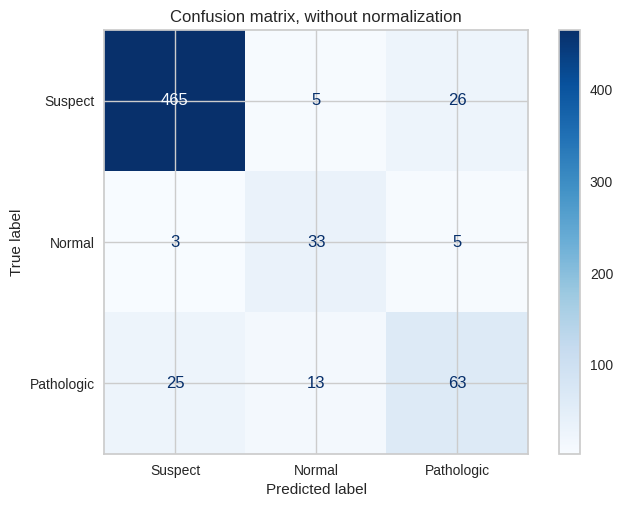

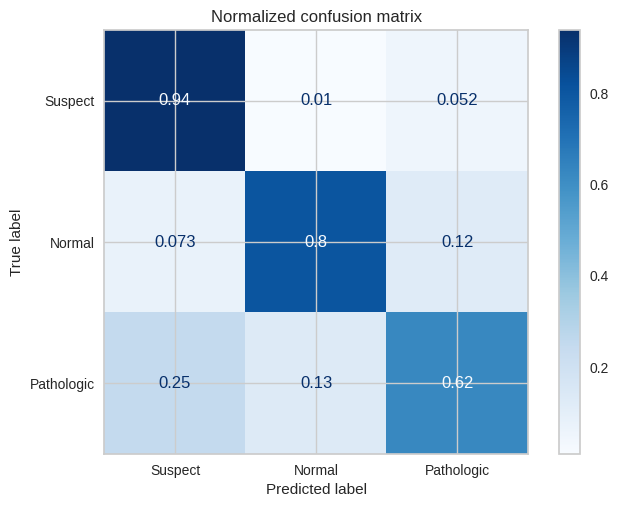

In [46]:
logistic_regression_func(
    path_to_df="https://raw.githubusercontent.com/SagarSharma4244/Fetal-Health/main/fetal_health.csv",
    target_column="fetal_health",
    grid_search_params=parameters,

)

In [47]:
model = LogisticRegression(
    multi_class= "multinomial",
    solver= "lbfgs", # Limited-memory Broyden-Fletcher-Goldfarb-Shanno generally good
    max_iter=50 #Maximum number of iterations taken for the solvers to converge.
)

## Visualize the training and loss curves

We shall use the visualizer package from yellow-bricks.

It uses crossvalidation which is basically how well a machine learning model performs on unseen data by splitting the dataset into several parts, training the model on some parts and testing it on the remaining part. This process is repeated multiple times on different parts of the dataset. The reslts from each validation are averaged to get the final performance.




/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid

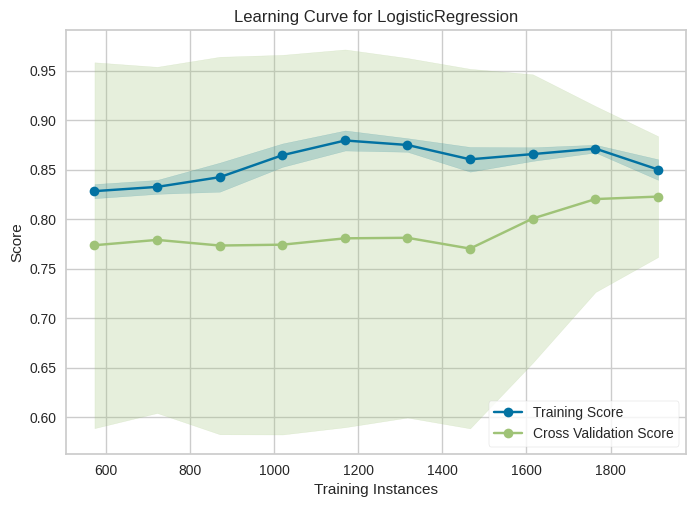

<Axes: title={'center': 'Learning Curve for LogisticRegression'}, xlabel='Training Instances', ylabel='Score'>

In [48]:
sizes = np.linspace(0.3, 1.0, 10)
visualizer = LearningCurve(
    model, cv=10, scoring="f1_weighted", train_sizes=sizes, n_jobs=-1
)

visualizer.fit(X, y)
visualizer.show()

## Feature Importances

Permutation feature importance is a model inspection technique that measures the contribution of each feature to a fitted model’s statistical performance on a given tabular dataset. This technique is particularly useful for non-linear or opaque estimators, and involves randomly shuffling the values of a single feature and observing the resulting degradation of the model’s score [1]. By breaking the relationship between the feature and the target, we determine how much the model relies on such particular feature.

[Ref](https://scikit-learn.org/stable/modules/permutation_importance.html)

In [49]:
from sklearn.inspection import permutation_importance

In [50]:
# Standardize
scaler = StandardScaler()
X_standardized = X.copy()
X_standardized[features] = scaler.fit_transform(X[features])
X_standardized.head()

# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_standardized, y, test_size=0.3, random_state=42
)


In [51]:
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



LogisticRegression(max_iter=50, multi_class='multinomial')

In [52]:
# Permutation Importance
perm_importance = permutation_importance(model, X_test, y_test, n_repeats=30, random_state=42, n_jobs=-1)
perm_importance_df = pd.DataFrame({
    'Feature': X_standardized.columns,
    'Importance Mean': perm_importance.importances_mean,
    'Importance Std': perm_importance.importances_std
})
print("\nPermutation Importance:")
print(perm_importance_df.sort_values(by='Importance Mean', ascending=False))


Permutation Importance:
                                              Feature  Importance Mean  \
17                                     histogram_mean         0.106844   
1                                       accelerations         0.081034   
7                     abnormal_short_term_variability         0.040491   
19                                 histogram_variance         0.025183   
16                                     histogram_mode         0.018757   
0                                      baseline value         0.016823   
6                            prolongued_decelerations         0.015674   
9   percentage_of_time_with_abnormal_long_term_var...         0.014890   
18                                   histogram_median         0.014420   
3                                uterine_contractions         0.008255   
14                          histogram_number_of_peaks         0.005434   
13                                      histogram_max         0.002665   
10           

In [53]:
perm_importance_df = perm_importance_df.sort_values(by='Importance Mean', ascending=False)
perm_importance_df.head(20)

,Feature,Importance Mean,Importance Std
17,histogram_mean,0.106844,0.011194
1,accelerations,0.081034,0.010215
7,abnormal_short_term_variability,0.040491,0.009889
19,histogram_variance,0.025183,0.005489
16,histogram_mode,0.018757,0.008089
0,baseline value,0.016823,0.007678
6,prolongued_decelerations,0.015674,0.004488
9,percentage_of_time_with_abnormal_long_term_var...,0.014890,0.006027
18,histogram_median,0.014420,0.006630
3,uterine_contractions,0.008255,0.007549


In [54]:
fig = px.bar(perm_importance_df,
             x="Importance Mean",
             y="Feature",
             color="Importance Mean"
             )

fig.show()